# Workshop 3: Data Visualization for Decision Makers

## Applied Data Science Workshop Series

**Focus:** Turning analysis into clear, decision-ready visuals.

In this workshop, you will learn how to:

- Create effective visualizations
- Identify common visualization problems
- Clean messy data before visualization
- Detect missing values, placeholder codes, and outliers
- Improve chart readability
- Write short insight statements for decision-makers

# 1. Key Libraries Used

## Pandas
Used for loading, cleaning, filtering, and summarizing datasets.

## NumPy
Used for numerical operations and for creating missing values in the synthetic dataset.

## Matplotlib
A core Python visualization library used to create and customize charts.

## Seaborn
A statistical visualization library built on Matplotlib. It makes it easier to create polished charts such as scatterplots, histograms, and boxplots.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_theme(style="whitegrid")


# Workshop colour palette — navy, gold, ice blue
NAVY  = "#1E2761"
GOLD  = "#C9A84C"
ICE   = "#CADCFC"
sns.set_palette([NAVY, GOLD, ICE])
print("Setup complete.")

Setup complete.


# 2. Load / Create a Synthetic Teaching Dataset

This dataset is based on the theme of **digital inequity in New Jersey**.

It includes intentionally messy data so we can practice cleaning before visualization.

The dataset includes:

- Missing values
- Outliers
- Special placeholder codes such as `666666`
- Variables related to income, education, and internet access

In [8]:
# ============================================================
# LOAD DATA
# ============================================================

DATA_FILE = "digital_inequity_nj_messy_synthetic.csv"

try:
    from google.colab import files
    print("Upload your CSV file if you have it. You may cancel upload to use generated demo data.")
    uploaded = files.upload()
    if len(uploaded) > 0:
        DATA_FILE = list(uploaded.keys())[0]
except Exception:
    print("Not running in Colab or upload skipped. Looking for a local CSV file.")

def generate_messy_demo_data(n=140, seed=123):
    rng = np.random.default_rng(seed)
    counties = [
        "Bergen", "Essex", "Hudson", "Middlesex", "Monmouth", "Morris",
        "Passaic", "Union", "Camden", "Mercer", "Ocean", "Burlington"
    ]

    county = rng.choice(counties, size=n)
    tract_id = [f"NJ-{i:03d}" for i in range(1, n + 1)]
    median_income = rng.normal(78000, 23000, n).clip(25000, 165000)
    bachelor_degree_rate = rng.normal(38, 14, n).clip(5, 78)
    poverty_rate = rng.normal(12, 6, n).clip(1, 35)
    unemployment_rate = rng.normal(6, 2, n).clip(1, 16)

    internet_access_rate = (
        58
        + (median_income - 50000) / 3000
        + bachelor_degree_rate * 0.25
        - poverty_rate * 0.40
        + rng.normal(0, 5, n)
    )
    internet_access_rate = np.clip(internet_access_rate, 35, 99)

    broadband_subscription_rate = np.clip(
        internet_access_rate - rng.normal(3, 4, n),
        25,
        99
    )

    data = pd.DataFrame({
        "tract_id": tract_id,
        "county": county,
        "median_income": np.round(median_income, 0),
        "internet_access_rate": np.round(internet_access_rate, 1),
        "broadband_subscription_rate": np.round(broadband_subscription_rate, 1),
        "bachelor_degree_rate": np.round(bachelor_degree_rate, 1),
        "poverty_rate": np.round(poverty_rate, 1),
        "unemployment_rate": np.round(unemployment_rate, 1),
    })

    # Inject missing values
    for col, k in [("median_income", 6), ("internet_access_rate", 5),
                   ("bachelor_degree_rate", 4), ("poverty_rate", 4)]:
        idx = rng.choice(data.index, size=k, replace=False)
        data.loc[idx, col] = np.nan

    # Inject special placeholder codes
    data.loc[rng.choice(data.index, size=5, replace=False), "median_income"] = 666666
    data.loc[rng.choice(data.index, size=3, replace=False), "internet_access_rate"] = 999
    data.loc[rng.choice(data.index, size=3, replace=False), "bachelor_degree_rate"] = -999
    data.loc[rng.choice(data.index, size=2, replace=False), "poverty_rate"] = 666666

    # Inject outliers and impossible values
    data.loc[rng.choice(data.index, size=2, replace=False), "median_income"] = [350000, 5000]
    data.loc[rng.choice(data.index, size=2, replace=False), "internet_access_rate"] = [130, -5]
    data.loc[rng.choice(data.index, size=2, replace=False), "broadband_subscription_rate"] = [122, -10]

    # Add one duplicate row
    data = pd.concat([data, data.iloc[[0]]], ignore_index=True)
    return data

if os.path.exists(DATA_FILE):
    raw_data = pd.read_csv(DATA_FILE)
    print(f"Loaded file: {DATA_FILE}")
else:
    raw_data = generate_messy_demo_data()
    print("No CSV found. Generated messy synthetic demo data.")
df= raw_data.copy()
df.head()

Upload your CSV file if you have it. You may cancel upload to use generated demo data.


Saving digital_inequity_nj_messy_synthetic.csv to digital_inequity_nj_messy_synthetic.csv
Loaded file: digital_inequity_nj_messy_synthetic.csv


,tract_id,county,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
0,NJ-001,Bergen,84835.0,71.2,65.3,5.3,7.6,8.5
1,NJ-002,Camden,67915.0,75.0,66.0,53.8,13.9,4.2
2,NJ-003,Union,73132.0,76.8,73.1,74.8,13.8,4.6
3,NJ-004,Bergen,86371.0,81.1,78.0,44.3,19.1,3.4
4,NJ-005,Ocean,99918.0,75.0,70.4,41.3,20.2,9.7


# 3. Initial Dataset Review

Before making visualizations, always inspect the dataset.

We want to know:

- How many rows and columns are present?
- What are the variable names?
- Are the data types correct?
- Are there missing values?
- Do summary statistics reveal unusual values?

In [9]:
df.shape

(141, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tract_id                     141 non-null    object 
 1   county                       141 non-null    object 
 2   median_income                135 non-null    float64
 3   internet_access_rate         136 non-null    float64
 4   broadband_subscription_rate  141 non-null    float64
 5   bachelor_degree_rate         137 non-null    float64
 6   poverty_rate                 137 non-null    float64
 7   unemployment_rate            141 non-null    float64
dtypes: float64(6), object(2)
memory usage: 8.9+ KB


In [11]:
df.describe()

,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
count,135.000000,136.000000,141.000000,137.000000,137.000000,141.000000
mean,104031.118519,93.234559,69.277305,14.449635,9743.878102,6.059574
std,115066.104974,137.130888,13.093343,152.924229,80251.439478,2.108587
min,5000.000000,-5.000000,-10.000000,-999.000000,1.000000,1.000000
25%,69442.000000,67.900000,63.000000,27.200000,7.500000,4.700000
50%,81099.000000,72.950000,69.200000,39.300000,11.600000,6.100000
75%,96854.500000,79.300000,76.800000,47.100000,15.900000,7.800000
max,666666.000000,999.000000,122.000000,74.800000,666666.000000,10.800000


# 4. Identify Missing Values

Missing values can distort charts, summary statistics, and model results.

In Python, missing values often appear as `NaN`.

In [12]:
df.isna().sum()

,0
tract_id,0
county,0
median_income,6
internet_access_rate,5
broadband_subscription_rate,0
bachelor_degree_rate,4
poverty_rate,4
unemployment_rate,0


# 5. Identify Special Placeholder Codes

Real-world datasets often use numeric codes to represent missing, suppressed, or unavailable data.

Examples:

- `666666`
- `777777`
- `999`
- `-999`

These should usually be converted to missing values before analysis.

In [13]:
placeholder_codes = [666666, 777777, 999, -999]

for col in ["median_income", "bachelor_degree_rate", "internet_access_rate"]:
    print(f"\nColumn: {col}")
    display(df[df[col].isin(placeholder_codes)][["county", col]])


Column: median_income


,county,median_income
21,Passaic,666666.0
83,Passaic,666666.0
90,Camden,666666.0
108,Union,666666.0
129,Monmouth,666666.0



Column: bachelor_degree_rate


,county,bachelor_degree_rate
82,Monmouth,-999.0
136,Passaic,-999.0
137,Burlington,-999.0



Column: internet_access_rate


,county,internet_access_rate
11,Mercer,999.0
40,Mercer,999.0
134,Monmouth,999.0


# 6. Replace Placeholder Codes with Missing Values

We replace special codes with `NaN` so Python treats them as missing data.

In [14]:
df_clean = df.copy()

df_clean[["median_income", "bachelor_degree_rate", "internet_access_rate"]] = (
    df_clean[["median_income", "bachelor_degree_rate", "internet_access_rate"]]
    .replace(placeholder_codes, np.nan)
)

df_clean.isna().sum()

,0
tract_id,0
county,0
median_income,11
internet_access_rate,8
broadband_subscription_rate,0
bachelor_degree_rate,7
poverty_rate,4
unemployment_rate,0


# 7. Handle Missing Values

For this teaching example, we will use a simple strategy:

- Drop rows with missing values in key analysis columns

In real projects, the best approach depends on why the values are missing and the purpose of the analysis. Here we drop rows because we have enough observations and are focused on visualization rather than modelling.

In [15]:
analysis_df = df_clean.dropna(
    subset=["median_income", "bachelor_degree_rate", "internet_access_rate"]
).copy()

analysis_df.shape

(115, 8)

# 8. Detect Outliers

Outliers are values that are unusually high or low compared with the rest of the data.

Outliers are not always errors. They may represent:

- Real extreme cases
- Data entry issues
- Special populations or places
- Measurement problems

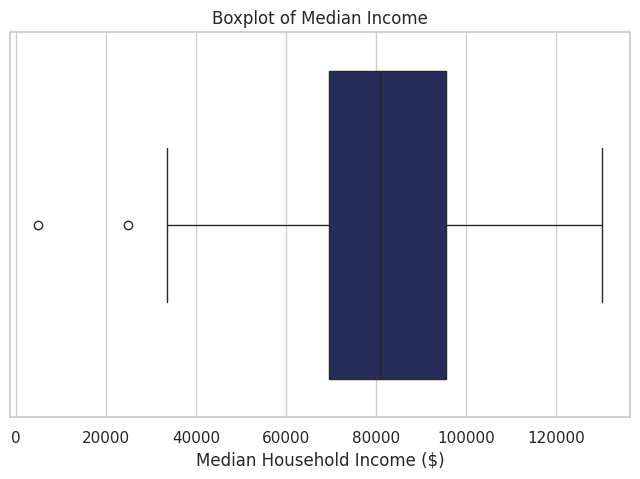

In [16]:
sns.boxplot(data=analysis_df, x="median_income")

plt.title("Boxplot of Median Income")
plt.xlabel("Median Household Income ($)")
plt.show()

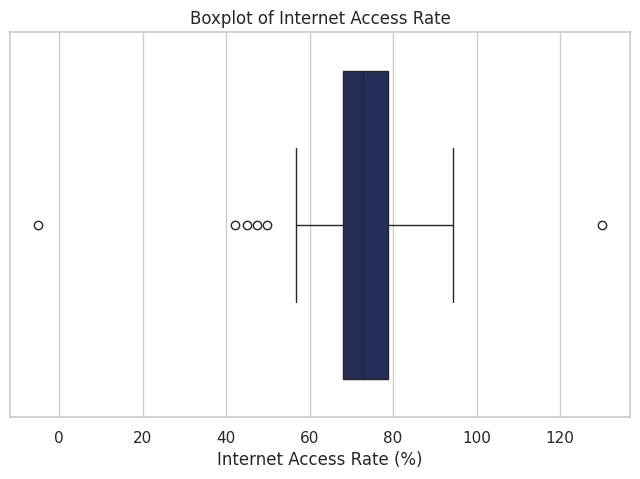

In [17]:
sns.boxplot(data=analysis_df, x="internet_access_rate")

plt.title("Boxplot of Internet Access Rate")
plt.xlabel("Internet Access Rate (%)")
plt.show()

# 9. Flag Outliers Using the IQR Method

The Interquartile Range method identifies values far below or above the middle 50% of the data.

This is a common rule-of-thumb method for detecting potential outliers.

In [18]:
def flag_iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

income_outliers = flag_iqr_outliers(analysis_df, "median_income")
access_outliers = flag_iqr_outliers(analysis_df, "internet_access_rate")

income_outliers[["county", "median_income"]]

,county,median_income
45,Morris,25000.0
113,Ocean,5000.0


In [19]:
access_outliers[["county", "internet_access_rate"]]

,county,internet_access_rate
19,Ocean,-5.0
27,Hudson,130.0
43,Essex,45.1
45,Morris,49.7
92,Morris,42.1
131,Bergen,47.3


# 10. Poor Visualization Example

This chart technically works, but it is not very polished.

Problems may include:

- Vague title
- Unclear axis labels
- No context
- No insight statement

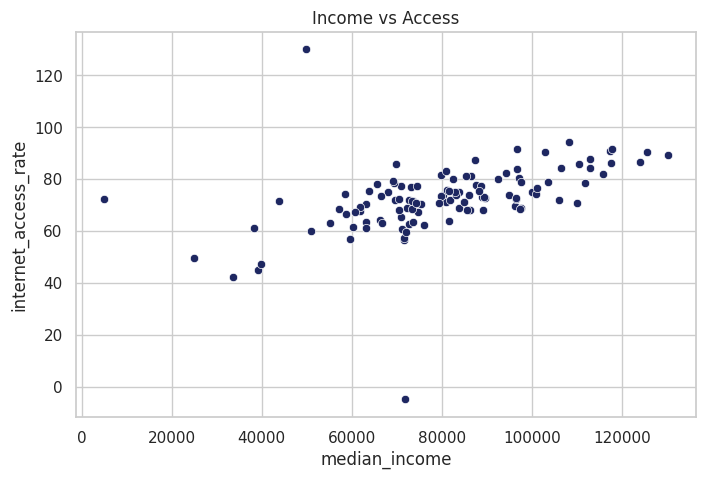

In [20]:
sns.scatterplot(
    data=analysis_df,
    x="median_income",
    y="internet_access_rate"
)

plt.title("Income vs Access")
plt.show()

### A Second Example: A Misleading Bar Chart

This bar chart has a different problem — the y-axis does not start at zero, which exaggerates the differences between groups and can mislead decision-makers.

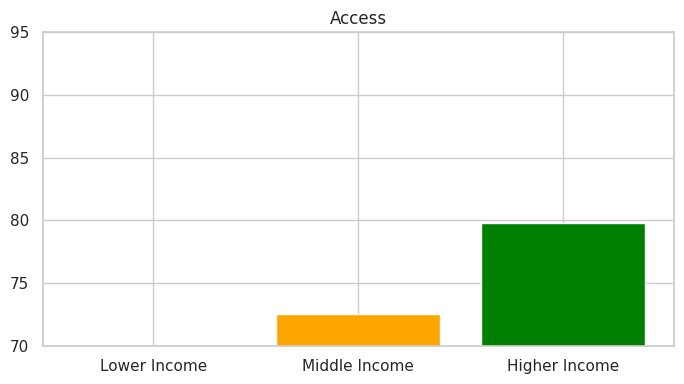

❌  Problems: y-axis starts at 70 (not 0), arbitrary colors, no labels, vague title.


In [21]:
# --- Poor visualization example 2: truncated y-axis ---
fig, ax = plt.subplots(figsize=(7, 4))

if "income_group" not in analysis_df.columns:
    analysis_df["income_group"] = pd.qcut(
        analysis_df["median_income"], q=3,
        labels=["Lower Income", "Middle Income", "Higher Income"]
    )

quick_summary = (
    analysis_df.groupby("income_group", observed=True)["internet_access_rate"]
    .mean()
)

ax.bar(quick_summary.index, quick_summary.values,
       color=["red", "orange", "green"])   # arbitrary, clashing colors

ax.set_ylim(70, 95)   # does not start at zero — gap looks huge
ax.set_title("Access")  # vague
# no axis labels

plt.tight_layout()
plt.show()

print("❌  Problems: y-axis starts at 70 (not 0), arbitrary colors, no labels, vague title.")

# 11. Improved Visualization

Now we improve the chart by adding:

- A clearer title
- Descriptive axis labels
- Better formatting
- A trend line
- A short caption/interpretation

In [22]:
#Remove outliers

all_outlier_indices = pd.Index(income_outliers.index).union(access_outliers.index)
analysis_df_no_outliers = analysis_df.drop(all_outlier_indices).copy()

print(f"Original DataFrame shape: {analysis_df.shape}")
print(f"DataFrame shape after removing outliers: {analysis_df_no_outliers.shape}")

Original DataFrame shape: (115, 9)
DataFrame shape after removing outliers: (108, 9)


The `analysis_df_no_outliers` DataFrame now contains the data with outliers removed from 'median_income' and 'internet_access_rate'.

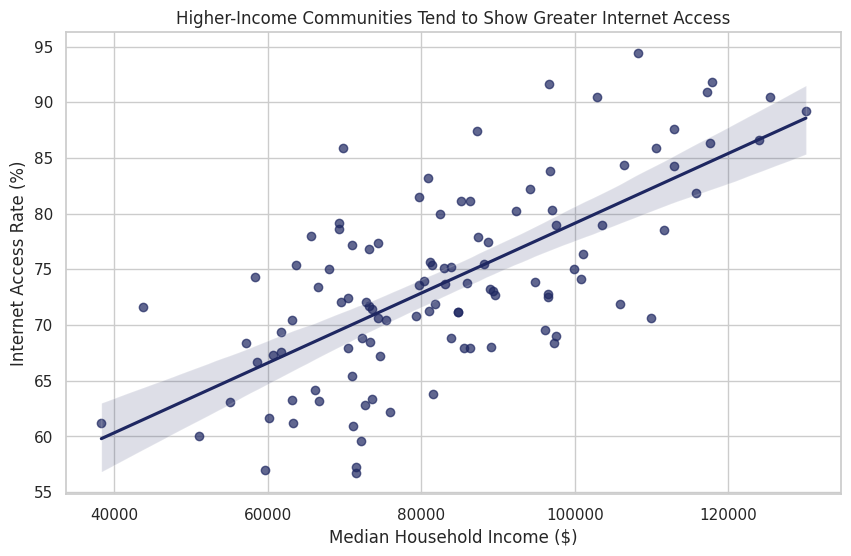

In [23]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=analysis_df_no_outliers,
    x="median_income",
    y="internet_access_rate",
    scatter_kws={"alpha": 0.7}
)

plt.title("Higher-Income Communities Tend to Show Greater Internet Access")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Internet Access Rate (%)")

plt.ticklabel_format(style="plain", axis="x")

plt.show()

## Insight Statement Example

The scatterplot suggests a positive relationship between median household income and internet access rate. This means higher-income communities generally appear to have higher rates of internet access in this synthetic dataset.

A decision-maker may use this pattern to investigate whether lower-income communities need additional broadband infrastructure support or digital inclusion programs.

## 📋 Storytelling Framework — Fill In Your Own

Use this template to turn any chart into a decision-ready narrative:

| Element | Your answer |
|---|---|
| **Situation** — what is the context? | *e.g., "We are examining digital equity across 120 NJ communities."* |
| **Complication** — what problem does the data reveal? | *e.g., "Lower-income communities have substantially lower internet access rates."* |
| **Resolution** — what does your chart show or recommend? | *e.g., "The scatterplot shows a consistent positive relationship between income and access."* |
| **Ask** — what action or decision does this support? | *e.g., "Target broadband subsidies at communities below $60 k median income."* |

> **Tip:** A strong chart title is usually your Resolution sentence, shortened to 10 words or fewer.

# 12. Distribution Visualization

A histogram helps us understand how internet access rates are distributed across communities.

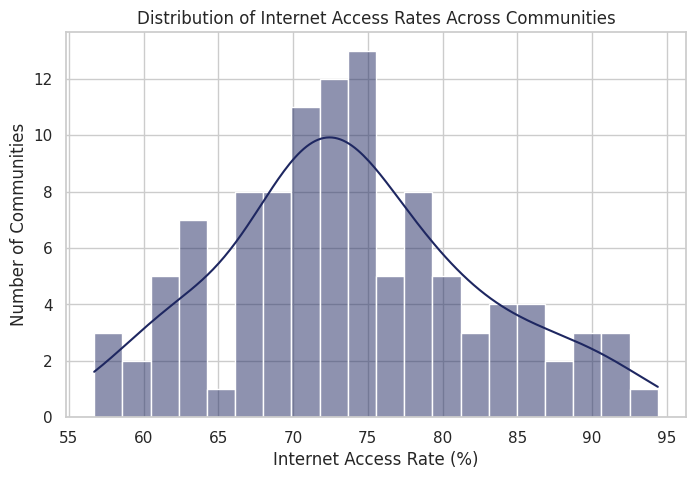

In [24]:
sns.histplot(
    data=analysis_df_no_outliers,
    x="internet_access_rate",
    bins=20,
    kde=True
)

plt.title("Distribution of Internet Access Rates Across Communities")
plt.xlabel("Internet Access Rate (%)")
plt.ylabel("Number of Communities")

plt.show()

# 12b. Trend Visualization — Line Chart

Line charts are the right choice when you want to show **how a value changes over time**.

Here we simulate a six-year trend in average internet access to illustrate the pattern.

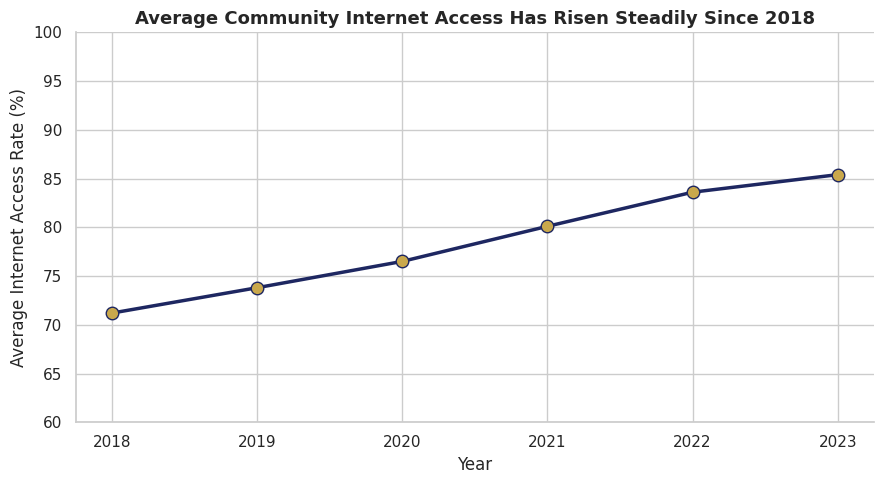

💡 Insight: Access improved ~14 percentage points over six years,
   but the absolute level still leaves room for targeted intervention.


In [ ]:
# Simulated year-over-year trend (illustrative)
years = [2018, 2019, 2020, 2021, 2022, 2023]
avg_access = [71.2, 73.8, 76.5, 80.1, 83.6, 85.4]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(years, avg_access, color=NAVY, linewidth=2.5, marker="o",
        markerfacecolor=GOLD, markeredgecolor=NAVY, markersize=9)

ax.set_title("Average Community Internet Access Has Risen Steadily Since 2018",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Average Internet Access Rate (%)")
ax.set_ylim(60, 100)
ax.set_xticks(years)

sns.despine()
plt.tight_layout()
plt.show()

print("💡 Insight: Access improved ~14 percentage points over six years,")
print("   but the absolute level still leaves room for targeted intervention.")

# 12c. Geographic Pattern — Choropleth-Style Chart

When data has a geographic component, a **map** lets decision-makers see spatial clusters at a glance.

Below is a simplified county-level grid showing simulated average access by region. In practice, use a proper shapefile with `geopandas` for production maps.

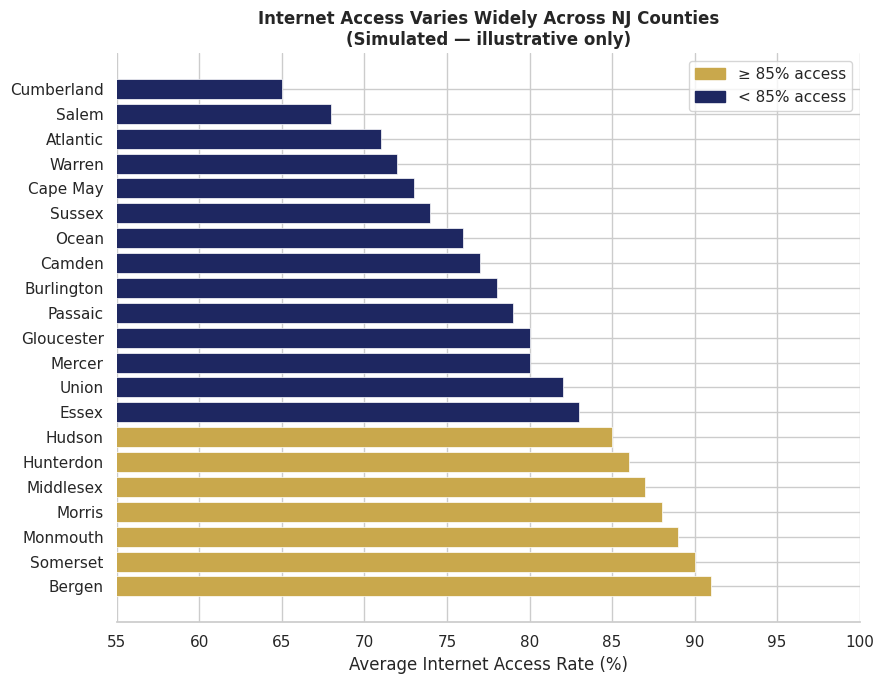

💡 Insight: Southern and western counties show consistently lower access rates,
   suggesting geographic targeting for broadband investment.


In [7]:
# Simulated county averages (illustrative — not real NJ data)
county_data = {
    "Bergen":     91, "Passaic":   79, "Sussex":  74,
    "Essex":      83, "Morris":    88, "Warren":  72,
    "Hudson":     85, "Union":     82, "Hunterdon": 86,
    "Middlesex":  87, "Somerset":  90, "Mercer":  80,
    "Monmouth":   89, "Burlington": 78, "Ocean":   76,
    "Atlantic":   71, "Cape May":  73, "Camden":  77,
    "Gloucester": 80, "Salem":     68, "Cumberland": 65,
}

# Convert to DataFrame for easy sorting
county_df = pd.DataFrame(list(county_data.items()), columns=['county', 'access_rate'])
county_df = county_df.sort_values(by='access_rate', ascending=False)

names = county_df['county'].tolist()
values = county_df['access_rate'].tolist()

# Simple horizontal bar chart as proxy for map
fig, ax = plt.subplots(figsize=(9, 7))
colors = [GOLD if v >= 85 else NAVY for v in values]

bars = ax.barh(names, values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlim(55, 100)
ax.set_xlabel("Average Internet Access Rate (%)")
ax.set_title("Internet Access Varies Widely Across NJ Counties\n"
             "(Simulated — illustrative only)", fontsize=12, fontweight="bold")

high_patch = mpatches.Patch(color=GOLD, label="≥ 85% access")
low_patch  = mpatches.Patch(color=NAVY, label="< 85% access")
ax.legend(handles=[high_patch, low_patch], loc="upper right")

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

print("💡 Insight: Southern and western counties show consistently lower access rates,")
print("   suggesting geographic targeting for broadband investment.")

# 13. Compare Groups by Income Category

Decision-makers often need simplified categories.

Here, we create income groups and compare average internet access rates.

In [ ]:
analysis_df["income_group"] = pd.qcut(
    analysis_df["median_income"],
    q=3,
    labels=["Lower Income", "Middle Income", "Higher Income"]
)

group_summary = (
    analysis_df
    .groupby("income_group", observed=True)["internet_access_rate"]
    .mean()
    .reset_index()
)

group_summary

,income_group,internet_access_rate
0,Lower Income,65.841026
1,Middle Income,72.539474
2,Higher Income,79.818421


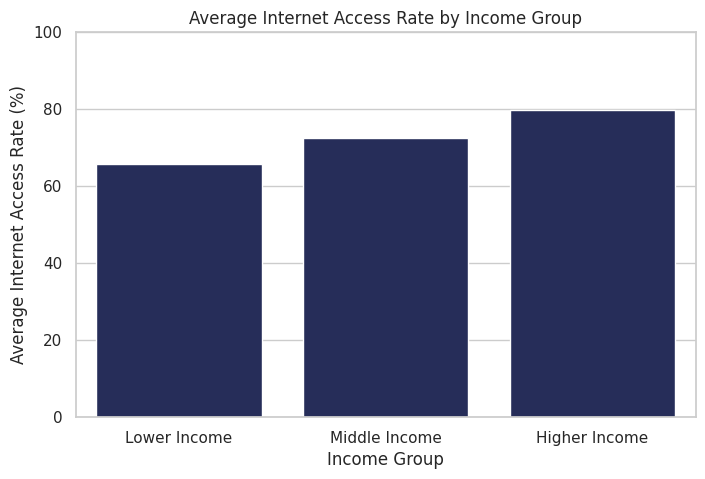

In [ ]:
sns.barplot(
    data=group_summary,
    x="income_group",
    y="internet_access_rate"
)

plt.title("Average Internet Access Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Internet Access Rate (%)")

plt.ylim(0, 100)

plt.show()

# 14. Improve the Bar Chart with an Insight-Focused Title

A strong title should explain the message, not just describe the chart.

/tmp/ipykernel_11254/2578731478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


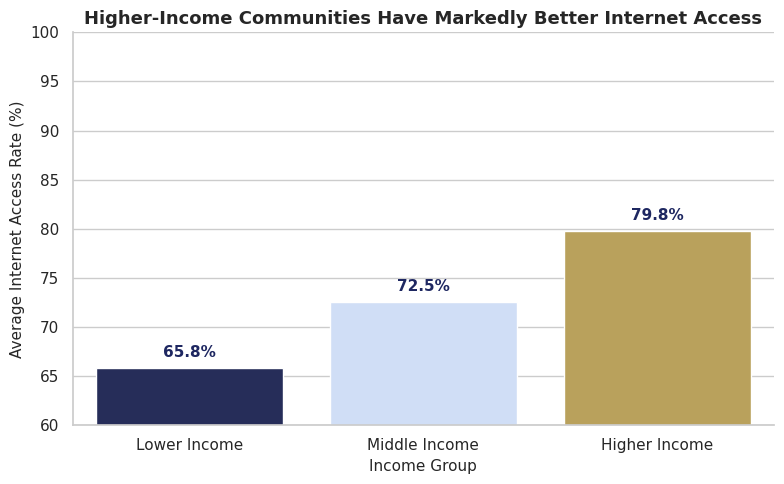

✅  Improvements over Section 13:
   • Workshop colour palette applied
   • Exact values labelled on each bar
   • Y-axis starts at 60 — honest scale that still shows the gap
   • Chart frame removed (despine) for a cleaner look


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = sns.barplot(
    data=group_summary,
    x="income_group",
    y="internet_access_rate",
    palette=[NAVY, ICE, GOLD],   # intentional: darkest = lowest income (draws the eye)
    ax=ax
)

# Value labels on each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold", color=NAVY
    )

ax.set_title("Higher-Income Communities Have Markedly Better Internet Access",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Income Group", fontsize=11)
ax.set_ylabel("Average Internet Access Rate (%)", fontsize=11)
ax.set_ylim(60, 100)   # tighter scale highlights real gap without distorting it

sns.despine()
plt.tight_layout()
plt.show()

print("✅  Improvements over Section 13:")
print("   • Workshop colour palette applied")
print("   • Exact values labelled on each bar")
print("   • Y-axis starts at 60 — honest scale that still shows the gap")
print("   • Chart frame removed (despine) for a cleaner look")

# 15. Student Activity

Use the dataset to create one improved visualization.

Your visualization should include:

- Clear chart type
- Descriptive title
- Labeled axes
- Appropriate scale
- One written insight statement

## Suggested Questions

1. How does education relate to internet access?
2. Do lower-income communities appear disadvantaged?
3. Are outliers affecting the interpretation?
4. What story does your chart tell?

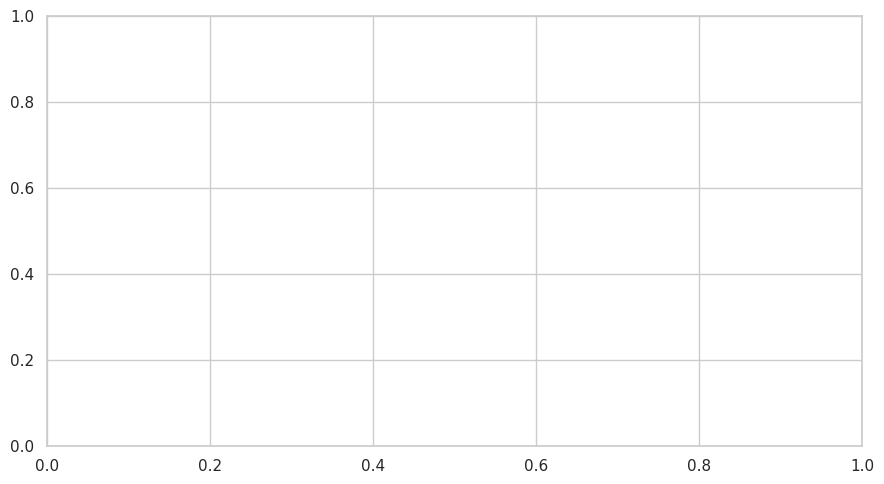

In [ ]:
# ── Student Activity ──────────────────────────────────────────────────────────
# Goal: create ONE improved visualization and write ONE insight statement.
#
# Step 1 — Choose your variables
#   Options: median_income, percent_bachelors_or_higher, internet_access_rate,
#            income_group
#   Question to answer: _________________________________________________

# Step 2 — Choose your chart type
#   Relationship between two numbers  →  scatterplot / regplot
#   Distribution of one variable      →  histogram / boxplot
#   Comparison across groups          →  bar chart
#   Change over time                  →  line chart

# Step 3 — Build the chart
fig, ax = plt.subplots(figsize=(9, 5))

# --- Replace this comment with your chart code ---
# Example starter (edit as needed):
# sns.scatterplot(data=analysis_df, x="median_income",
#                 y="percent_bachelors_or_higher",
#                 color=NAVY, alpha=0.7, ax=ax)

# Step 4 — Polish it
# ax.set_title("Your insight-driven title here")
# ax.set_xlabel("X-axis label")
# ax.set_ylabel("Y-axis label")
# sns.despine()

plt.tight_layout()
plt.show()

# Step 5 — Write your insight statement (delete this line and replace below)
# "This chart shows ____. This matters because ____. A decision-maker could use
#  this to ____."

# 16. Reflection Questions

Answer the following:

1. What did your visualization show?
2. Why does this finding matter?
3. What decision or policy question could this support?
4. What would you improve if you had more time or more data?

#Add your insights here:

# Key Takeaways

- Visualization is about communication, not decoration.
- Messy data must be cleaned before reliable visualization.
- Missing values, special codes, and outliers can distort charts.
- Good charts make the main message easier to understand.
- A strong visualization should be paired with a clear insight statement.

## Suggested Extension

After the workshop, participants can:

- Add Additional Variables to the Visualization e.g. Create a scatterplot that includes: income, internet access and education level
- improve charts using customized colors, labels, subtitles etc.
- write a 3–4 sentence insight summary of of the visual

---

## Learning Objectives — Check-In

At the start of this workshop, we set five goals. Review them and reflect on which you feel confident about.

1. ✅ Understand principles of effective data visualization
2. ✅ Identify common visualization mistakes
3. ✅ Improve chart readability and storytelling
4. ✅ Communicate insights clearly to decision-makers
5. ✅ Create polished visualizations using Python